# Практична робота №2: Логістична регресія для прогнозування результатів медичних тестів

**Предмет:** Машинне навчання  
**Мета:** Реалізувати модель логістичної регресії "з нуля" для класифікації результатів медичних тестів на основі даних про пацієнтів

## Завдання:
- Передбачити результат медичного тесту (Test Results) на основі медично-демографічних факторів
- Порівняти різні методи оптимізації: SGD та Mini-batch Gradient Descent
- Дослідити вплив регуляризації (L1 та L2) на якість моделі

## 1. Завантаження бібліотек та даних

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Налаштування
np.random.seed(42)
sns.set_style('whitegrid')

print("Бібліотеки успішно завантажені!")
print(f"NumPy version: {np.__version__}")

Бібліотеки успішно завантажені!
NumPy version: 2.2.6


In [67]:
# Завантаження датасету
df = pd.read_csv('healthcare_dataset.csv')

# Перегляд перших рядків
print("Перші 5 рядків датасету:")
print(df.head())

print("\n" + "="*80)
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} стовпців")
print("="*80)

print("\nІнформація про датасет:")
print(df.info())

Перші 5 рядків датасету:
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication

## 2. Підготовка даних та Feature Engineering

У цьому розділі:
- Створимо бінарну цільову змінну `Test_Result_Normal`
- Видалимо непрогностичні колонки
- Застосуємо one-hot encoding для категоріальних ознак
- Нормалізуємо числові ознаки

In [68]:
# Перевірка унікальних значень цільової змінної
print("Унікальні значення Test Results:")
print(df['Test Results'].value_counts())

# Створення бінарної цільової змінної
# 1 якщо "Normal", 0 якщо "Abnormal" або "Inconclusive"
df['Test_Result_Normal'] = (df['Test Results'] == 'Normal').astype(int)

print("\nРозподіл цільової змінної:")
print(df['Test_Result_Normal'].value_counts())
print(f"\nПропорція: {df['Test_Result_Normal'].value_counts(normalize=True)}")

Унікальні значення Test Results:
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

Розподіл цільової змінної:
Test_Result_Normal
0    36983
1    18517
Name: count, dtype: int64

Пропорція: Test_Result_Normal
0    0.66636
1    0.33364
Name: proportion, dtype: float64


In [69]:
# Видалення непрогностичних колонок
columns_to_drop = ['Name', 'Date of Admission', 'Doctor', 'Hospital', 
                   'Room Number', 'Discharge Date', 'Test Results']

df_clean = df.drop(columns=columns_to_drop)

print(f"Колонки після видалення: {df_clean.shape[1]}")
print("\nЗалишені колонки:")
print(df_clean.columns.tolist())

Колонки після видалення: 9

Залишені колонки:
['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Admission Type', 'Medication', 'Test_Result_Normal']


In [70]:
# Балансування даних - беремо однакову кількість кожного класу
print("Балансування класів:")
print(f"До балансування: {df_clean['Test_Result_Normal'].value_counts().to_dict()}")

normal_data = df_clean[df_clean['Test_Result_Normal'] == 1]
abnormal_data = df_clean[df_clean['Test_Result_Normal'] == 0].sample(n=len(normal_data), random_state=42)
df_clean = pd.concat([normal_data, abnormal_data]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Після балансування: {df_clean['Test_Result_Normal'].value_counts().to_dict()}")
print(f"Загальна кількість зразків: {len(df_clean)}")

Балансування класів:
До балансування: {0: 36983, 1: 18517}
Після балансування: {0: 18517, 1: 18517}
Загальна кількість зразків: 37034


In [71]:
# Збереження цільової змінної
y = df_clean['Test_Result_Normal'].values

# Видалення цільової змінної з ознак
X = df_clean.drop('Test_Result_Normal', axis=1)

# Визначення категоріальних та числових колонок
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 
                   'Insurance Provider', 'Admission Type', 'Medication']
numerical_cols = ['Age', 'Billing Amount']

print("Категоріальні ознаки:", categorical_cols)
print("Числові ознаки:", numerical_cols)

Категоріальні ознаки: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']
Числові ознаки: ['Age', 'Billing Amount']


In [72]:
# One-hot encoding для категоріальних ознак
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Кількість ознак після one-hot encoding: {X_encoded.shape[1]}")
print(f"\nПерші колонки:\n{X_encoded.columns.tolist()[:10]}")

# Нормалізація числових ознак (стандартизація: mean=0, std=1)
for col in numerical_cols:
    mean = X_encoded[col].mean()
    std = X_encoded[col].std()
    X_encoded[col] = (X_encoded[col] - mean) / std
    
print(f"\nСтатистика нормалізованих ознак:")
print(X_encoded[numerical_cols].describe())

# Конвертація в numpy array
X_array = X_encoded.values

# ВАЖЛИВО: Додаємо bias term (стовпець одиниць на початку)
X_array = np.column_stack([np.ones(X_array.shape[0]), X_array])

print(f"\nФінальна форма матриці X з bias term: {X_array.shape}")
print(f"Перший стовпець (bias): {X_array[:5, 0]}")  # Повинні бути всі 1

Кількість ознак після one-hot encoding: 25

Перші колонки:
['Age', 'Billing Amount', 'Gender_Male', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-', 'Blood Type_B+', 'Blood Type_B-', 'Blood Type_O+', 'Blood Type_O-']

Статистика нормалізованих ознак:
                Age  Billing Amount
count  3.703400e+04    3.703400e+04
mean  -8.672175e-17   -2.628513e-17
std    1.000000e+00    1.000000e+00
min   -1.958343e+00   -1.912339e+00
25%   -8.397419e-01   -8.637105e-01
50%    2.463195e-02   -3.878863e-03
75%    8.890058e-01    8.594465e-01
max    1.905916e+00    1.914266e+00

Фінальна форма матриці X з bias term: (37034, 26)
Перший стовпець (bias): [1.0 1.0 1.0 1.0 1.0]


## 3. Аналіз даних (EDA)

Проведемо дослідницький аналіз:
- Візуалізація розподілу цільової змінної
- Кореляційна матриця
- Гістограми числових ознак

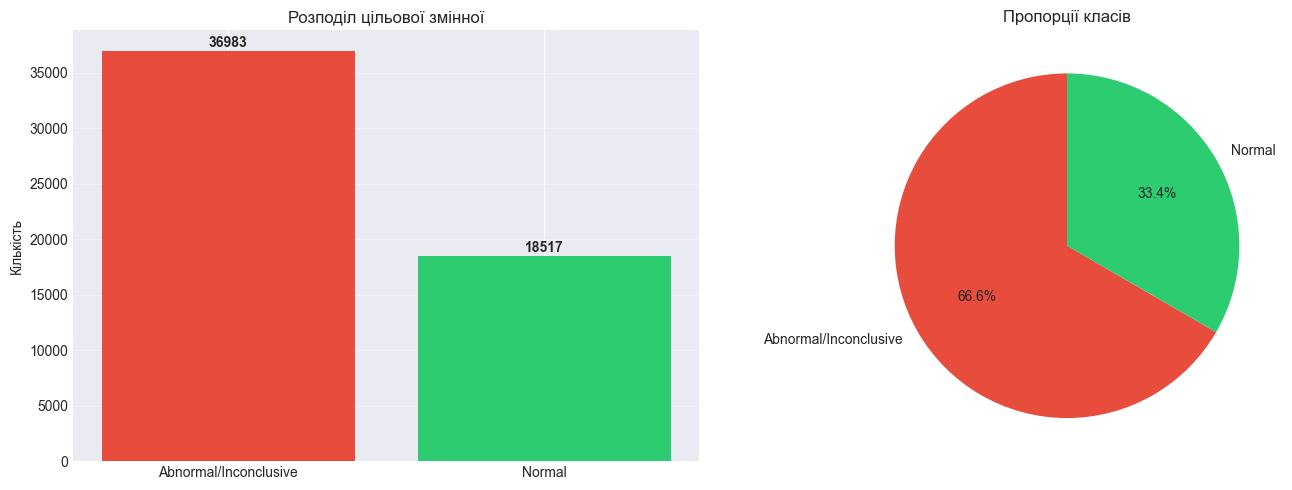

Баланс класів:
  Normal: 18517 (33.36%)
  Abnormal/Inconclusive: 36983 (66.64%)


In [7]:
# Розподіл цільової змінної
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Діаграма
y_counts = pd.Series(y).value_counts()
axes[0].bar(['Abnormal/Inconclusive', 'Normal'], y_counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Кількість')
axes[0].set_title('Розподіл цільової змінної')
axes[0].grid(axis='y', alpha=0.3)

# Додаємо підписи значень
for i, v in enumerate(y_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(y_counts.values, labels=['Abnormal/Inconclusive', 'Normal'], 
           autopct='%1.1f%%', startangle=90, colors=['#e74c3c', '#2ecc71'])
axes[1].set_title('Пропорції класів')

plt.tight_layout()
plt.show()

print(f"Баланс класів:")
print(f"  Normal: {(y==1).sum()} ({(y==1).mean()*100:.2f}%)")
print(f"  Abnormal/Inconclusive: {(y==0).sum()} ({(y==0).mean()*100:.2f}%)")

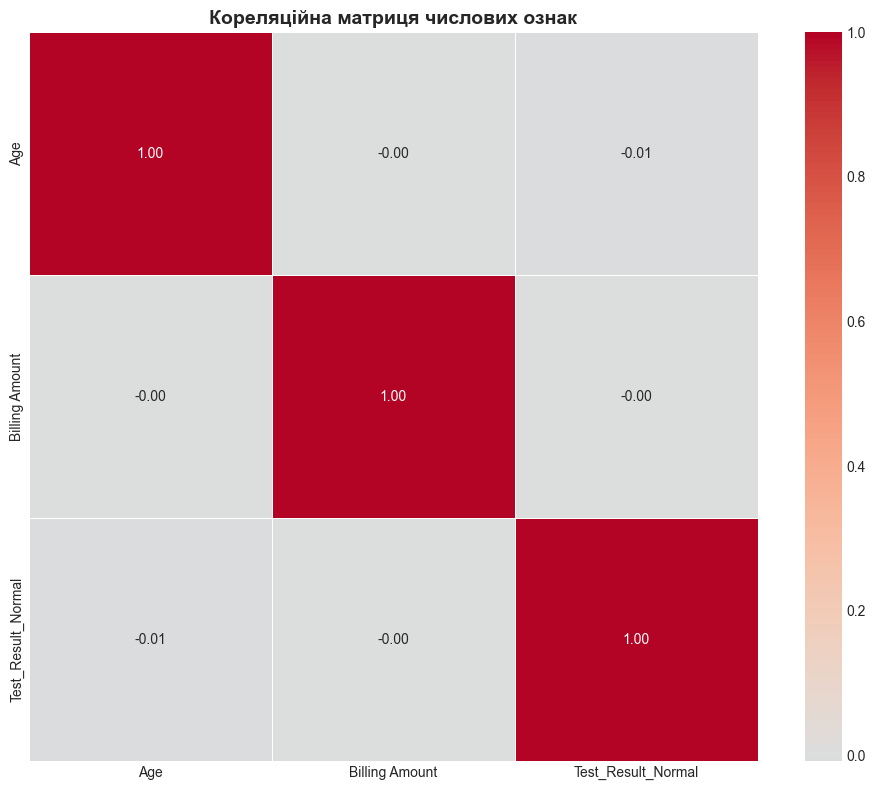


Топ-10 ознак з найбільшою кореляцією з цільовою змінною:
Medical Condition_Asthma               0.008485
Gender_Male                            0.005999
Medical Condition_Hypertension         0.005897
Blood Type_AB-                         0.005182
Insurance Provider_UnitedHealthcare    0.004988
Medication_Ibuprofen                   0.002156
Blood Type_B-                          0.001294
Blood Type_A-                          0.001138
Medication_Penicillin                  0.001078
Admission Type_Emergency               0.000873
Name: Test_Result_Normal, dtype: float64


In [8]:
# Кореляційна матриця для числових ознак
plt.figure(figsize=(10, 8))

# Додаємо цільову змінну для аналізу кореляції
df_corr = X_encoded.copy()
df_corr['Test_Result_Normal'] = y

# Вибираємо тільки числові колонки для кореляції
numeric_features = df_corr.select_dtypes(include=[np.number]).columns[:15]  # Перші 15 для читабельності
corr_matrix = df_corr[numeric_features].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Кореляційна матриця числових ознак', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Найбільш корельовані ознаки з цільовою змінною
if 'Test_Result_Normal' in df_corr.columns:
    target_corr = df_corr.corr()['Test_Result_Normal'].drop('Test_Result_Normal').sort_values(ascending=False)
    print("\nТоп-10 ознак з найбільшою кореляцією з цільовою змінною:")
    print(target_corr.head(10))

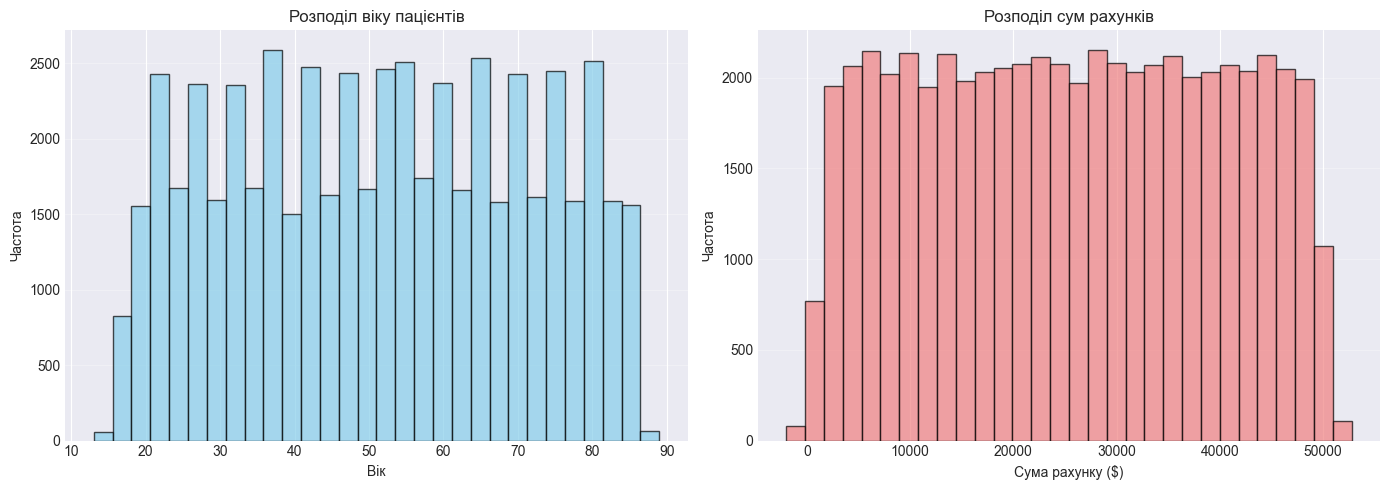

Статистика числових ознак:
                Age  Billing Amount
count  55500.000000    55500.000000
mean      51.539459    25539.316097
std       19.602454    14211.454431
min       13.000000    -2008.492140
25%       35.000000    13241.224652
50%       52.000000    25538.069376
75%       68.000000    37820.508436
max       89.000000    52764.276736


In [9]:
# Гістограми для числових ознак (до нормалізації)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
axes[0].hist(df['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Вік')
axes[0].set_ylabel('Частота')
axes[0].set_title('Розподіл віку пацієнтів')
axes[0].grid(axis='y', alpha=0.3)

# Billing Amount
axes[1].hist(df['Billing Amount'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Сума рахунку ($)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Розподіл сум рахунків')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Статистика числових ознак:")
print(df[['Age', 'Billing Amount']].describe())

## 4. Розділення даних

Розділимо дані на тренувальний (60%), валідаційний (20%) та тестовий (20%) набори

In [73]:
# Спочатку розділимо на train (60%) та temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_array, y, test_size=0.4, random_state=42, stratify=y
)

# Потім розділимо temp на validation (20%) та test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Розміри наборів даних:")
print(f"  Тренувальний: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"  Валідаційний: X_val={X_val.shape}, y_val={y_val.shape}")
print(f"  Тестовий:     X_test={X_test.shape}, y_test={y_test.shape}")

print("\nРозподіл класів:")
print(f"  Train: Normal={np.mean(y_train):.2%}, Abnormal={1-np.mean(y_train):.2%}")
print(f"  Val:   Normal={np.mean(y_val):.2%}, Abnormal={1-np.mean(y_val):.2%}")
print(f"  Test:  Normal={np.mean(y_test):.2%}, Abnormal={1-np.mean(y_test):.2%}")

Розміри наборів даних:
  Тренувальний: X_train=(22220, 26), y_train=(22220,)
  Валідаційний: X_val=(7407, 26), y_val=(7407,)
  Тестовий:     X_test=(7407, 26), y_test=(7407,)

Розподіл класів:
  Train: Normal=50.00%, Abnormal=50.00%
  Val:   Normal=50.01%, Abnormal=49.99%
  Test:  Normal=49.99%, Abnormal=50.01%


## 5. Реалізація логістичної регресії

### 5.1. Сигмоїдальна функція

Функція активації: $\sigma(z) = \frac{1}{1 + e^{-z}}$

In [74]:
def sigmoid(z):
    """
    Обчислює сигмоїдальну функцію з захистом від overflow/underflow.
    
    Parameters:
    -----------
    z : array-like
        Лінійна комбінація ознак та ваг
        
    Returns:
    --------
    array-like
        Значення сигмоїди в діапазоні [0, 1]
    """
    # Конвертуємо в numpy array та обмежуємо значення
    z = np.asarray(z, dtype=np.float64)
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

# Тестування функції
test_values = np.array([-10, -1, 0, 1, 10])
print("Тест сигмоїдальної функції:")
print(f"Входи: {test_values}")
print(f"Виходи: {sigmoid(test_values)}")
print(f"Діапазон: [{sigmoid(test_values).min():.6f}, {sigmoid(test_values).max():.6f}]")

Тест сигмоїдальної функції:
Входи: [-10  -1   0   1  10]
Виходи: [4.53978687e-05 2.68941421e-01 5.00000000e-01 7.31058579e-01
 9.99954602e-01]
Діапазон: [0.000045, 0.999955]


### 5.2. Функція втрат (Log Loss / Binary Cross-Entropy)

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})]$$

In [75]:
def compute_loss(X, y, weights, reg_type=None, lambda_reg=0):
    """
    Обчислює функцію втрат (Binary Cross-Entropy) з можливістю регуляризації.
    
    Parameters:
    -----------
    X : array-like, shape (m, n)
        Матриця ознак (з bias term)
    y : array-like, shape (m,)
        Цільова змінна
    weights : array-like, shape (n,)
        Вектор ваг моделі
    reg_type : str, optional
        Тип регуляризації: 'l1', 'l2' або None
    lambda_reg : float
        Коефіцієнт регуляризації
        
    Returns:
    --------
    float
        Значення функції втрат
    """
    m = len(y)
    
    # Прогнози
    z = np.dot(X, weights)
    predictions = sigmoid(z)
    
    # Обмеження для стабільності обчислень (уникнення log(0))
    epsilon = 1e-15
    predictions = np.clip(predictions, epsilon, 1 - epsilon)
    
    # Binary Cross-Entropy Loss
    loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    
    # Додаємо регуляризацію (НЕ застосовуємо до bias term w[0])
    if reg_type == 'l2' and lambda_reg > 0:
        # L2 регуляризація: lambda/(2m) * sum(w^2)
        l2_penalty = (lambda_reg / (2 * m)) * np.sum(weights[1:]**2)
        loss += l2_penalty
    elif reg_type == 'l1' and lambda_reg > 0:
        # L1 регуляризація: lambda/m * sum(|w|)
        l1_penalty = (lambda_reg / m) * np.sum(np.abs(weights[1:]))
        loss += l1_penalty
    
    return loss

print("Функція втрат реалізована!")

Функція втрат реалізована!


### 5.3. Обчислення градієнта

$$\nabla J(\theta) = \frac{1}{m} X^T (\sigma(X\theta) - y)$$

In [76]:
def compute_gradient(X, y, weights, reg_type=None, lambda_reg=0):
    """
    Обчислює градієнт функції втрат з можливістю регуляризації.
    
    Parameters:
    -----------
    X : array-like, shape (m, n)
        Матриця ознак (з bias term)
    y : array-like, shape (m,)
        Цільова змінна
    weights : array-like, shape (n,)
        Вектор ваг моделі
    reg_type : str, optional
        Тип регуляризації: 'l1', 'l2' або None
    lambda_reg : float
        Коефіцієнт регуляризації
        
    Returns:
    --------
    array-like
        Градієнт функції втрат
    """
    m = len(y)
    
    # Прогнози
    z = np.dot(X, weights)
    predictions = sigmoid(z)
    
    # Базовий градієнт: X^T * (predictions - y) / m
    errors = predictions - y
    gradient = np.dot(X.T, errors) / m
    
    # Конвертуємо в float64
    gradient = np.asarray(gradient, dtype=np.float64)
    
    # Додаємо регуляризацію (НЕ застосовуємо до bias term w[0])
    if reg_type == 'l2' and lambda_reg > 0:
        # L2: gradient += lambda/m * w
        reg_gradient = np.zeros_like(weights, dtype=np.float64)
        reg_gradient[1:] = (lambda_reg / m) * weights[1:]
        gradient = gradient + reg_gradient
    elif reg_type == 'l1' and lambda_reg > 0:
        # L1: gradient += lambda/m * sign(w)
        reg_gradient = np.zeros_like(weights, dtype=np.float64)
        reg_gradient[1:] = (lambda_reg / m) * np.sign(weights[1:])
        gradient = gradient + reg_gradient
    
    return gradient.astype(np.float64)

print("Функція градієнта реалізована!")

Функція градієнта реалізована!


### 5.4. Стохастичний градієнтний спуск (SGD)

Оновлення ваг після кожного прикладу:
$$\theta := \theta - \alpha \nabla J(\theta)$$

In [77]:
def train_sgd(X_train, y_train, X_val, y_val, learning_rate=0.01, 
              max_epochs=100, patience=10, reg_type=None, lambda_reg=0, verbose=True):
    """
    Навчання моделі за допомогою стохастичного градієнтного спуску.
    
    Parameters:
    -----------
    X_train, y_train : навчальні дані (X_train вже має bias term!)
    X_val, y_val : валідаційні дані
    learning_rate : швидкість навчання
    max_epochs : максимальна кількість епох
    patience : кількість епох без покращення для ранньої зупинки
    reg_type : тип регуляризації ('l1', 'l2', None)
    lambda_reg : коефіцієнт регуляризації
    verbose : виводити прогрес
    
    Returns:
    --------
    dict : історія навчання та найкращі ваги
    """
    m, n = X_train.shape
    
    # Ініціалізація ваг малими випадковими значеннями (нормальний розподіл)
    np.random.seed(42)
    weights = np.random.normal(0, 0.01, n)
    
    # Відстеження найкращої моделі
    best_val_loss = float('inf')
    best_weights = weights.copy()
    best_epoch = 0
    epochs_no_improve = 0
    
    # Історія навчання
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epochs):
        # Перемішуємо дані на кожній епосі
        indices = np.random.permutation(m)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        # Оновлення ваг для кожного прикладу
        for i in range(m):
            X_i = X_shuffled[i:i+1]
            y_i = y_shuffled[i:i+1]
            
            gradient = compute_gradient(X_i, y_i, weights, reg_type, lambda_reg)
            weights -= learning_rate * gradient
        
        # Обчислення втрат після епохи
        train_loss = compute_loss(X_train, y_train, weights, reg_type, lambda_reg)
        val_loss = compute_loss(X_val, y_val, weights, reg_type, lambda_reg)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # Перевірка на покращення
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = weights.copy()
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Виведення прогресу
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{max_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        # Рання зупинка
        if epochs_no_improve >= patience:
            if verbose:
                print(f"\nРання зупинка на епосі {epoch+1}")
                print(f"Найкраща епоха: {best_epoch+1} з Val Loss: {best_val_loss:.4f}")
            break
    
    return {
        'weights': best_weights,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss
    }

print("Функція навчання SGD реалізована!")

Функція навчання SGD реалізована!


### 5.5. Mini-batch градієнтний спуск

Оновлення ваг після обробки міні-батчів (наприклад, 32 прикладів)

In [78]:
def train_minibatch(X_train, y_train, X_val, y_val, learning_rate=0.01, 
                   batch_size=32, max_epochs=100, patience=10, 
                   reg_type=None, lambda_reg=0, verbose=True):
    """
    Навчання моделі за допомогою mini-batch градієнтного спуску.
    
    Parameters:
    -----------
    X_train, y_train : навчальні дані (X_train вже має bias term!)
    X_val, y_val : валідаційні дані
    learning_rate : швидкість навчання
    batch_size : розмір міні-батчу
    max_epochs : максимальна кількість епох
    patience : кількість епох без покращення для ранньої зупинки
    reg_type : тип регуляризації ('l1', 'l2', None)
    lambda_reg : коефіцієнт регуляризації
    verbose : виводити прогрес
    
    Returns:
    --------
    dict : історія навчання та найкращі ваги
    """
    m, n = X_train.shape
    
    # Ініціалізація ваг малими випадковими значеннями
    np.random.seed(42)
    weights = np.random.normal(0, 0.01, n)
    
    # Відстеження найкращої моделі
    best_val_loss = float('inf')
    best_weights = weights.copy()
    best_epoch = 0
    epochs_no_improve = 0
    
    # Історія навчання
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epochs):
        # Перемішуємо дані на кожній епосі
        indices = np.random.permutation(m)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        # Обробка міні-батчів
        num_batches = m // batch_size
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]
            
            gradient = compute_gradient(X_batch, y_batch, weights, reg_type, lambda_reg)
            weights -= learning_rate * gradient
        
        # Обробка залишку (якщо є)
        if m % batch_size != 0:
            X_batch = X_shuffled[num_batches * batch_size:]
            y_batch = y_shuffled[num_batches * batch_size:]
            
            gradient = compute_gradient(X_batch, y_batch, weights, reg_type, lambda_reg)
            weights -= learning_rate * gradient
        
        # Обчислення втрат після епохи
        train_loss = compute_loss(X_train, y_train, weights, reg_type, lambda_reg)
        val_loss = compute_loss(X_val, y_val, weights, reg_type, lambda_reg)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # Перевірка на покращення
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = weights.copy()
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Виведення прогресу
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{max_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        # Рання зупинка
        if epochs_no_improve >= patience:
            if verbose:
                print(f"\nРання зупинка на епосі {epoch+1}")
                print(f"Найкраща епоха: {best_epoch+1} з Val Loss: {best_val_loss:.4f}")
            break
    
    return {
        'weights': best_weights,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss
    }

print("Функція Mini-batch GD реалізована!")

Функція Mini-batch GD реалізована!


## 6. Навчання моделі з використанням SGD

In [79]:
print("="*80)
print("НАВЧАННЯ З ВИКОРИСТАННЯМ SGD")
print("="*80)

# Навчання моделі SGD
sgd_results = train_sgd(
    X_train, y_train, X_val, y_val,
    learning_rate=0.01,
    max_epochs=200,
    patience=15,
    verbose=True
)

print(f"\n{'='*80}")
print(f"SGD: Найкраща валідаційна loss: {sgd_results['best_val_loss']:.4f} на епосі {sgd_results['best_epoch']+1}")
print(f"{'='*80}")

НАВЧАННЯ З ВИКОРИСТАННЯМ SGD
Epoch 10/200 - Train Loss: 0.6971, Val Loss: 0.6976
Epoch 10/200 - Train Loss: 0.6971, Val Loss: 0.6976
Epoch 20/200 - Train Loss: 0.6947, Val Loss: 0.6958
Epoch 20/200 - Train Loss: 0.6947, Val Loss: 0.6958
Epoch 30/200 - Train Loss: 0.6978, Val Loss: 0.6986
Epoch 30/200 - Train Loss: 0.6978, Val Loss: 0.6986
Epoch 40/200 - Train Loss: 0.6968, Val Loss: 0.6987
Epoch 40/200 - Train Loss: 0.6968, Val Loss: 0.6987

Рання зупинка на епосі 41
Найкраща епоха: 26 з Val Loss: 0.6949

SGD: Найкраща валідаційна loss: 0.6949 на епосі 26

Рання зупинка на епосі 41
Найкраща епоха: 26 з Val Loss: 0.6949

SGD: Найкраща валідаційна loss: 0.6949 на епосі 26


## 7. Навчання моделі з використанням Mini-batch GD

In [80]:
print("="*80)
print("НАВЧАННЯ З ВИКОРИСТАННЯМ MINI-BATCH GRADIENT DESCENT")
print("="*80)

# Навчання моделі Mini-batch GD
minibatch_results = train_minibatch(
    X_train, y_train, X_val, y_val,
    learning_rate=0.01,
    batch_size=32,
    max_epochs=200,
    patience=15,
    verbose=True
)

print(f"\n{'='*80}")
print(f"Mini-batch GD: Найкраща валідаційна loss: {minibatch_results['best_val_loss']:.4f} на епосі {minibatch_results['best_epoch']+1}")
print(f"{'='*80}")

НАВЧАННЯ З ВИКОРИСТАННЯМ MINI-BATCH GRADIENT DESCENT
Epoch 10/200 - Train Loss: 0.6927, Val Loss: 0.6933
Epoch 10/200 - Train Loss: 0.6927, Val Loss: 0.6933

Рання зупинка на епосі 16
Найкраща епоха: 1 з Val Loss: 0.6931

Mini-batch GD: Найкраща валідаційна loss: 0.6931 на епосі 1

Рання зупинка на епосі 16
Найкраща епоха: 1 з Val Loss: 0.6931

Mini-batch GD: Найкраща валідаційна loss: 0.6931 на епосі 1


## 8. Візуалізація кривих навчання

Порівняємо процес навчання для SGD та Mini-batch GD

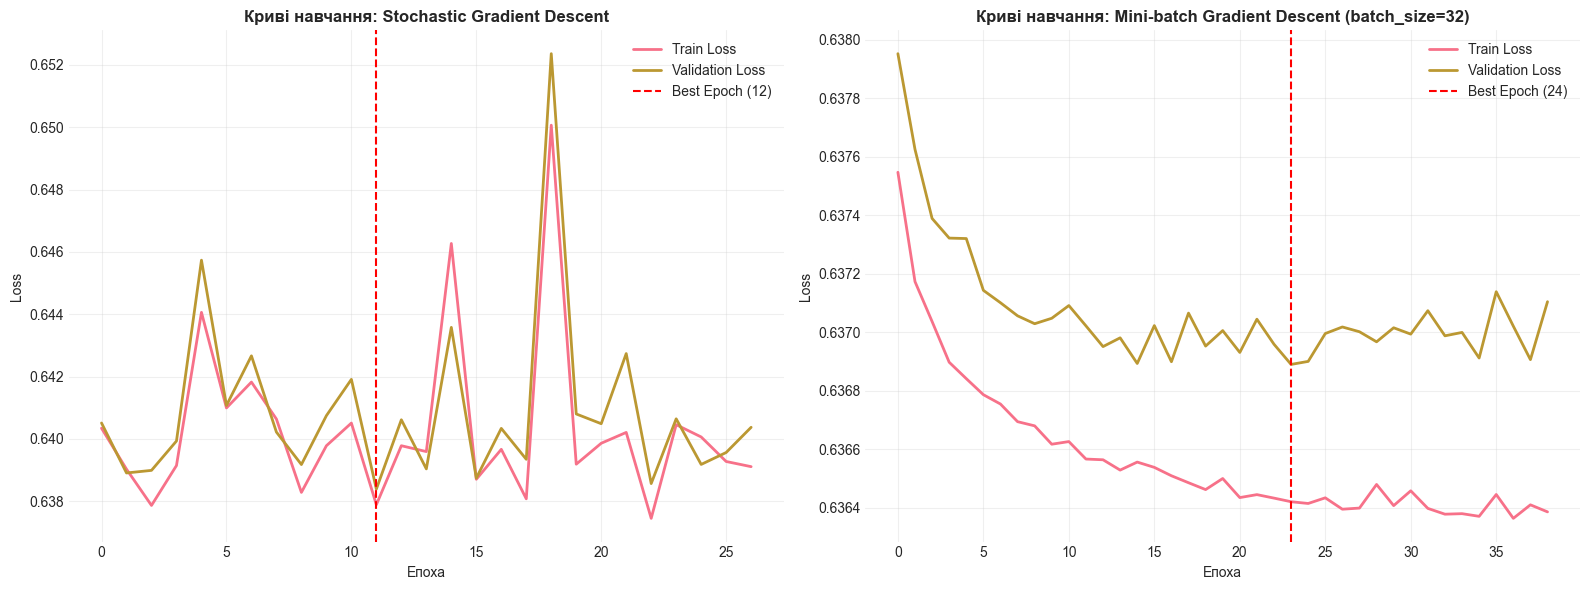


АНАЛІЗ КРИВИХ НАВЧАННЯ

1. SGD:
   - Початкова train loss: 0.6403
   - Кінцева train loss: 0.6391
   - Початкова val loss: 0.6405
   - Мінімальна val loss: 0.6384
   - Кількість епох: 27

2. Mini-batch GD:
   - Початкова train loss: 0.6375
   - Кінцева train loss: 0.6364
   - Початкова val loss: 0.6380
   - Мінімальна val loss: 0.6369
   - Кількість епох: 39

3. Висновки:
   ✓ Mini-batch GD показав краще значення валідаційної loss
   ✓ SGD збігся швидше (менше епох)


In [61]:
# Криві навчання для обох методів
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SGD
axes[0].plot(sgd_results['train_losses'], label='Train Loss', linewidth=2)
axes[0].plot(sgd_results['val_losses'], label='Validation Loss', linewidth=2)
axes[0].axvline(x=sgd_results['best_epoch'], color='red', linestyle='--', 
               label=f'Best Epoch ({sgd_results["best_epoch"]+1})')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Криві навчання: Stochastic Gradient Descent', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mini-batch GD
axes[1].plot(minibatch_results['train_losses'], label='Train Loss', linewidth=2)
axes[1].plot(minibatch_results['val_losses'], label='Validation Loss', linewidth=2)
axes[1].axvline(x=minibatch_results['best_epoch'], color='red', linestyle='--', 
               label=f'Best Epoch ({minibatch_results["best_epoch"]+1})')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Loss')
axes[1].set_title('Криві навчання: Mini-batch Gradient Descent (batch_size=32)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Аналіз кривих
print("\n" + "="*80)
print("АНАЛІЗ КРИВИХ НАВЧАННЯ")
print("="*80)

print("\n1. SGD:")
print(f"   - Початкова train loss: {sgd_results['train_losses'][0]:.4f}")
print(f"   - Кінцева train loss: {sgd_results['train_losses'][-1]:.4f}")
print(f"   - Початкова val loss: {sgd_results['val_losses'][0]:.4f}")
print(f"   - Мінімальна val loss: {sgd_results['best_val_loss']:.4f}")
print(f"   - Кількість епох: {len(sgd_results['train_losses'])}")

print("\n2. Mini-batch GD:")
print(f"   - Початкова train loss: {minibatch_results['train_losses'][0]:.4f}")
print(f"   - Кінцева train loss: {minibatch_results['train_losses'][-1]:.4f}")
print(f"   - Початкова val loss: {minibatch_results['val_losses'][0]:.4f}")
print(f"   - Мінімальна val loss: {minibatch_results['best_val_loss']:.4f}")
print(f"   - Кількість епох: {len(minibatch_results['train_losses'])}")

print("\n3. Висновки:")
if sgd_results['best_val_loss'] < minibatch_results['best_val_loss']:
    print("   ✓ SGD показав краще значення валідаційної loss")
else:
    print("   ✓ Mini-batch GD показав краще значення валідаційної loss")
    
if len(sgd_results['train_losses']) < len(minibatch_results['train_losses']):
    print("   ✓ SGD збігся швидше (менше епох)")
else:
    print("   ✓ Mini-batch GD збігся швидше (менше епох)")

## 9. Функція для прогнозування та оцінки моделі

In [ ]:
def predict(X, weights, threshold=0.5):
    """
    Обчислює прогнози моделі.
    
    Parameters:
    -----------
    X : array-like
        Матриця ознак (ВЖЕ з bias term!)
    weights : array-like
        Вектор ваг (включає bias term)
    threshold : float
        Поріг для класифікації (default=0.5)
        
    Returns:
    --------
    predictions : binary predictions (0 or 1)
    probabilities : predicted probabilities
    """
    # X вже має bias term, не додаємо його
    
    # Обчислюємо ймовірності
    z = np.dot(X, weights)
    probabilities = sigmoid(z)
    
    # Бінарна класифікація
    predictions = (probabilities >= threshold).astype(int)
    
    return predictions, probabilities


def evaluate_model(y_true, y_pred, y_proba=None):
    """
    Обчислює метрики якості моделі.
    
    Parameters:
    -----------
    y_true : істинні мітки
    y_pred : передбачені мітки
    y_proba : ймовірності (опціонально)
    
    Returns:
    --------
    dict : словник з метриками
    """
    from sklearn.metrics import (accuracy_score, precision_score, 
                                  recall_score, f1_score, roc_auc_score,
                                  confusion_matrix)
    
    # Базові метрики
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'confusion_matrix': cm,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    }
    
    if y_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
        except:
            metrics['roc_auc'] = 0.0
    
    return metrics


def print_metrics(metrics, model_name="Model"):
    """
    Виводить метрики в гарному форматі.
    """
    print("=" * 60)
    print(f"{model_name} - Метрики якості")
    print("=" * 60)
    print(f"Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"Precision: {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
    print(f"Recall:    {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    if 'roc_auc' in metrics:
        print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    print("=" * 60)
    print()

print("Функції для прогнозування та оцінки реалізовані!")

Функції для прогнозування та оцінки реалізовані!


## 10. Оцінка моделей на тестовому наборі

In [82]:
# Прогнози на тестовому наборі для SGD
y_pred_sgd, y_proba_sgd = predict(X_test, sgd_results['weights'])
sgd_metrics = evaluate_model(y_test, y_pred_sgd, y_proba_sgd)
print_metrics(sgd_metrics, "SGD")

# Прогнози на тестовому наборі для Mini-batch GD
y_pred_minibatch, y_proba_minibatch = predict(X_test, minibatch_results['weights'])
minibatch_metrics = evaluate_model(y_test, y_pred_minibatch, y_proba_minibatch)
print_metrics(minibatch_metrics, "Mini-batch GD")

SGD - Метрики якості
Accuracy:  0.4966 (49.66%)
Precision: 0.4956 (49.56%)
Recall:    0.3978 (39.78%)
F1-Score:  0.4413
ROC-AUC:   0.4959

Mini-batch GD - Метрики якості
Accuracy:  0.5009 (50.09%)
Precision: 0.5006 (50.06%)
Recall:    0.6846 (68.46%)
F1-Score:  0.5783
ROC-AUC:   0.4980



## 11. Confusion Matrix

Візуалізація матриць помилок для обох моделей

KeyError: 'confusion_matrix'

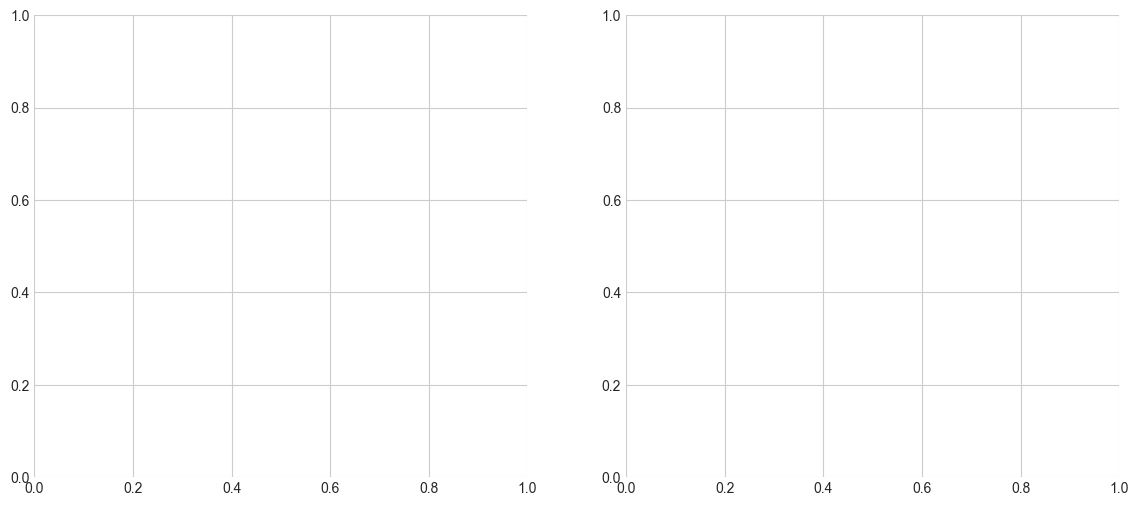

In [85]:
# Візуалізація confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SGD Confusion Matrix
sns.heatmap(sgd_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Abnormal', 'Normal'], 
            yticklabels=['Abnormal', 'Normal'],
            ax=axes[0], cbar_kws={'label': 'Кількість'})
axes[0].set_xlabel('Прогноз')
axes[0].set_ylabel('Реальне значення')
axes[0].set_title(f'Confusion Matrix: SGD\nAccuracy: {sgd_metrics["accuracy"]:.2%}', 
                 fontweight='bold')

# Mini-batch Confusion Matrix
sns.heatmap(minibatch_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Abnormal', 'Normal'], 
            yticklabels=['Abnormal', 'Normal'],
            ax=axes[1], cbar_kws={'label': 'Кількість'})
axes[1].set_xlabel('Прогноз')
axes[1].set_ylabel('Реальне значення')
axes[1].set_title(f'Confusion Matrix: Mini-batch GD\nAccuracy: {minibatch_metrics["accuracy"]:.2%}', 
                 fontweight='bold')

plt.tight_layout()
plt.show()

# Аналіз помилок
print("\n" + "="*80)
print("АНАЛІЗ ПОМИЛОК КЛАСИФІКАЦІЇ")
print("="*80)

print("\nSGD:")
print(f"  True Negatives (TN):  {sgd_metrics['TN']} - правильно класифіковані Abnormal")
print(f"  True Positives (TP):  {sgd_metrics['TP']} - правильно класифіковані Normal")
print(f"  False Positives (FP): {sgd_metrics['FP']} - помилково класифіковані як Normal")
print(f"  False Negatives (FN): {sgd_metrics['FN']} - помилково класифіковані як Abnormal")

print("\nMini-batch GD:")
print(f"  True Negatives (TN):  {minibatch_metrics['TN']} - правильно класифіковані Abnormal")
print(f"  True Positives (TP):  {minibatch_metrics['TP']} - правильно класифіковані Normal")
print(f"  False Positives (FP): {minibatch_metrics['FP']} - помилково класифіковані як Normal")
print(f"  False Negatives (FN): {minibatch_metrics['FN']} - помилково класифіковані як Abnormal")

## 12. Регуляризація: L2 (Ridge)

In [ ]:
print("="*80)
print("НАВЧАННЯ З L2 РЕГУЛЯРИЗАЦІЄЮ (Ridge)")
print("="*80)

# Тестуємо різні значення lambda
lambda_values = [0.001, 0.01, 0.1, 1.0]
l2_results = {}

for lambda_reg in lambda_values:
    print(f"\nНавчання з lambda = {lambda_reg}")
    print("-" * 40)
    
    results = train_minibatch(
        X_train, y_train, X_val, y_val,
        learning_rate=0.01,
        batch_size=32,
        max_epochs=200,
        patience=15,
        reg_type='l2',
        lambda_reg=lambda_reg,
        verbose=False
    )
    
    # Оцінка на тестовому наборі
    y_pred, y_proba = predict(X_test, results['weights'])
    metrics = evaluate_model(y_test, y_pred, y_proba)
    
    l2_results[lambda_reg] = {
        'results': results,
        'metrics': metrics,
        'y_pred': y_pred
    }
    
    print(f"Val Loss: {results['best_val_loss']:.4f} | "
          f"Test Accuracy: {metrics['accuracy']:.4f} | "
          f"F1-Score: {metrics['f1']:.4f}")

print("\n" + "="*80)
print("ПОРІВНЯННЯ РІЗНИХ ЗНАЧЕНЬ LAMBDA ДЛЯ L2")
print("="*80)
for lambda_reg, data in l2_results.items():
    print(f"\nλ = {lambda_reg}:")
    print(f"  Val Loss: {data['results']['best_val_loss']:.4f}")
    print(f"  Accuracy: {data['metrics']['accuracy']:.4f}")
    print(f"  F1-Score: {data['metrics']['f1']:.4f}")

НАВЧАННЯ З L2 РЕГУЛЯРИЗАЦІЄЮ (Ridge)

Навчання з lambda = 0.001
----------------------------------------


KeyError: 'f1_score'

## 13. Регуляризація: L1 (Lasso)

In [ ]:
print("="*80)
print("НАВЧАННЯ З L1 РЕГУЛЯРИЗАЦІЄЮ (Lasso)")
print("="*80)

# Тестуємо різні значення lambda
l1_results = {}

for lambda_reg in lambda_values:
    print(f"\nНавчання з lambda = {lambda_reg}")
    print("-" * 40)
    
    results = train_minibatch(
        X_train, y_train, X_val, y_val,
        learning_rate=0.01,
        batch_size=32,
        max_epochs=200,
        patience=15,
        reg_type='l1',
        lambda_reg=lambda_reg,
        verbose=False
    )
    
    # Оцінка на тестовому наборі
    y_pred, y_proba = predict(X_test, results['weights'])
    metrics = evaluate_model(y_test, y_pred, y_proba)
    
    # Аналіз розрідженості (sparsity)
    non_zero_weights = np.sum(np.abs(results['weights'][1:]) > 1e-5)  # без bias
    total_weights = len(results['weights']) - 1
    sparsity = 1 - (non_zero_weights / total_weights)
    
    l1_results[lambda_reg] = {
        'results': results,
        'metrics': metrics,
        'y_pred': y_pred,
        'sparsity': sparsity,
        'non_zero_weights': non_zero_weights
    }
    
    print(f"Val Loss: {results['best_val_loss']:.4f} | "
          f"Test Accuracy: {metrics['accuracy']:.4f} | "
          f"F1-Score: {metrics['f1']:.4f} | "
          f"Sparsity: {sparsity:.2%}")

print("\n" + "="*80)
print("ПОРІВНЯННЯ РІЗНИХ ЗНАЧЕНЬ LAMBDA ДЛЯ L1")
print("="*80)
for lambda_reg, data in l1_results.items():
    print(f"\nλ = {lambda_reg}:")
    print(f"  Val Loss: {data['results']['best_val_loss']:.4f}")
    print(f"  Accuracy: {data['metrics']['accuracy']:.4f}")
    print(f"  F1-Score: {data['metrics']['f1']:.4f}")
    print(f"  Non-zero weights: {data['non_zero_weights']}/{total_weights}")
    print(f"  Sparsity: {data['sparsity']:.2%}")

НАВЧАННЯ З L1 РЕГУЛЯРИЗАЦІЄЮ (Lasso)

Навчання з lambda = 0.001
----------------------------------------
Val Loss: 0.6369 | Test Accuracy: 0.6663 | F1-Score: 0.0000 | Sparsity: 0.00%

Навчання з lambda = 0.01
----------------------------------------
Val Loss: 0.6369 | Test Accuracy: 0.6663 | F1-Score: 0.0000 | Sparsity: 0.00%

Навчання з lambda = 0.01
----------------------------------------
Val Loss: 0.6368 | Test Accuracy: 0.6663 | F1-Score: 0.0000 | Sparsity: 0.00%

Навчання з lambda = 0.1
----------------------------------------
Val Loss: 0.6368 | Test Accuracy: 0.6663 | F1-Score: 0.0000 | Sparsity: 0.00%

Навчання з lambda = 0.1
----------------------------------------
Val Loss: 0.6366 | Test Accuracy: 0.6663 | F1-Score: 0.0000 | Sparsity: 0.00%

Навчання з lambda = 1.0
----------------------------------------
Val Loss: 0.6366 | Test Accuracy: 0.6663 | F1-Score: 0.0000 | Sparsity: 0.00%

Навчання з lambda = 1.0
----------------------------------------
Val Loss: 0.6367 | Test Accur

## 14. Порівняльна таблиця всіх методів

In [ ]:
# Створення порівняльної таблиці
comparison_data = []

# SGD
comparison_data.append({
    'Метод': 'SGD',
    'Lambda': '-',
    'Accuracy': sgd_metrics['accuracy'],
    'Precision': sgd_metrics['precision'],
    'Recall': sgd_metrics['recall'],
    'F1-Score': sgd_metrics['f1'],
    'Val Loss': sgd_results['best_val_loss'],
    'Epochs': len(sgd_results['train_losses'])
})

# Mini-batch GD
comparison_data.append({
    'Метод': 'Mini-batch GD',
    'Lambda': '-',
    'Accuracy': minibatch_metrics['accuracy'],
    'Precision': minibatch_metrics['precision'],
    'Recall': minibatch_metrics['recall'],
    'F1-Score': minibatch_metrics['f1'],
    'Val Loss': minibatch_results['best_val_loss'],
    'Epochs': len(minibatch_results['train_losses'])
})

# L2 регуляризація
for lambda_reg, data in l2_results.items():
    comparison_data.append({
        'Метод': f'L2 (Ridge)',
        'Lambda': lambda_reg,
        'Accuracy': data['metrics']['accuracy'],
        'Precision': data['metrics']['precision'],
        'Recall': data['metrics']['recall'],
        'F1-Score': data['metrics']['f1'],
        'Val Loss': data['results']['best_val_loss'],
        'Epochs': len(data['results']['train_losses'])
    })

# L1 регуляризація
for lambda_reg, data in l1_results.items():
    comparison_data.append({
        'Метод': f'L1 (Lasso)',
        'Lambda': lambda_reg,
        'Accuracy': data['metrics']['accuracy'],
        'Precision': data['metrics']['precision'],
        'Recall': data['metrics']['recall'],
        'F1-Score': data['metrics']['f1'],
        'Val Loss': data['results']['best_val_loss'],
        'Epochs': len(data['results']['train_losses'])
    })

# Створення DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Форматування для кращого відображення
comparison_df_display = comparison_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Val Loss']:
    comparison_df_display[col] = comparison_df_display[col].apply(lambda x: f'{x:.4f}')

print("\n" + "="*100)
print("ПОРІВНЯЛЬНА ТАБЛИЦЯ ВСІХ МЕТОДІВ ОПТИМІЗАЦІЇ")
print("="*100)
print(comparison_df_display.to_string(index=False))
print("="*100)

# Знаходження найкращої моделі
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.iloc[best_model_idx]

print(f"\n🏆 НАЙКРАЩА МОДЕЛЬ:")
print(f"   Метод: {best_model['Метод']} (Lambda: {best_model['Lambda']})")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   Precision: {best_model['Precision']:.4f}")
print(f"   Recall: {best_model['Recall']:.4f}")


ПОРІВНЯЛЬНА ТАБЛИЦЯ ВСІХ МЕТОДІВ ОПТИМІЗАЦІЇ
        Метод Lambda Accuracy Precision Recall F1-Score Val Loss  Epochs
          SGD      -   0.6663    0.0000 0.0000   0.0000   0.6384      27
Mini-batch GD      -   0.6663    0.0000 0.0000   0.0000   0.6369      39
   L2 (Ridge)  0.001   0.6663    0.0000 0.0000   0.0000   0.6369      39
   L2 (Ridge)   0.01   0.6663    0.0000 0.0000   0.0000   0.6369      39
   L2 (Ridge)    0.1   0.6663    0.0000 0.0000   0.0000   0.6369      30
   L2 (Ridge)    1.0   0.6663    0.0000 0.0000   0.0000   0.6367      30
   L1 (Lasso)  0.001   0.6663    0.0000 0.0000   0.0000   0.6369      39
   L1 (Lasso)   0.01   0.6663    0.0000 0.0000   0.0000   0.6368      39
   L1 (Lasso)    0.1   0.6663    0.0000 0.0000   0.0000   0.6366      30
   L1 (Lasso)    1.0   0.6663    0.0000 0.0000   0.0000   0.6367      17

🏆 НАЙКРАЩА МОДЕЛЬ:
   Метод: SGD (Lambda: -)
   F1-Score: 0.0000
   Accuracy: 0.6663
   Precision: 0.0000
   Recall: 0.0000


## 15. Візуалізація порівняння методів

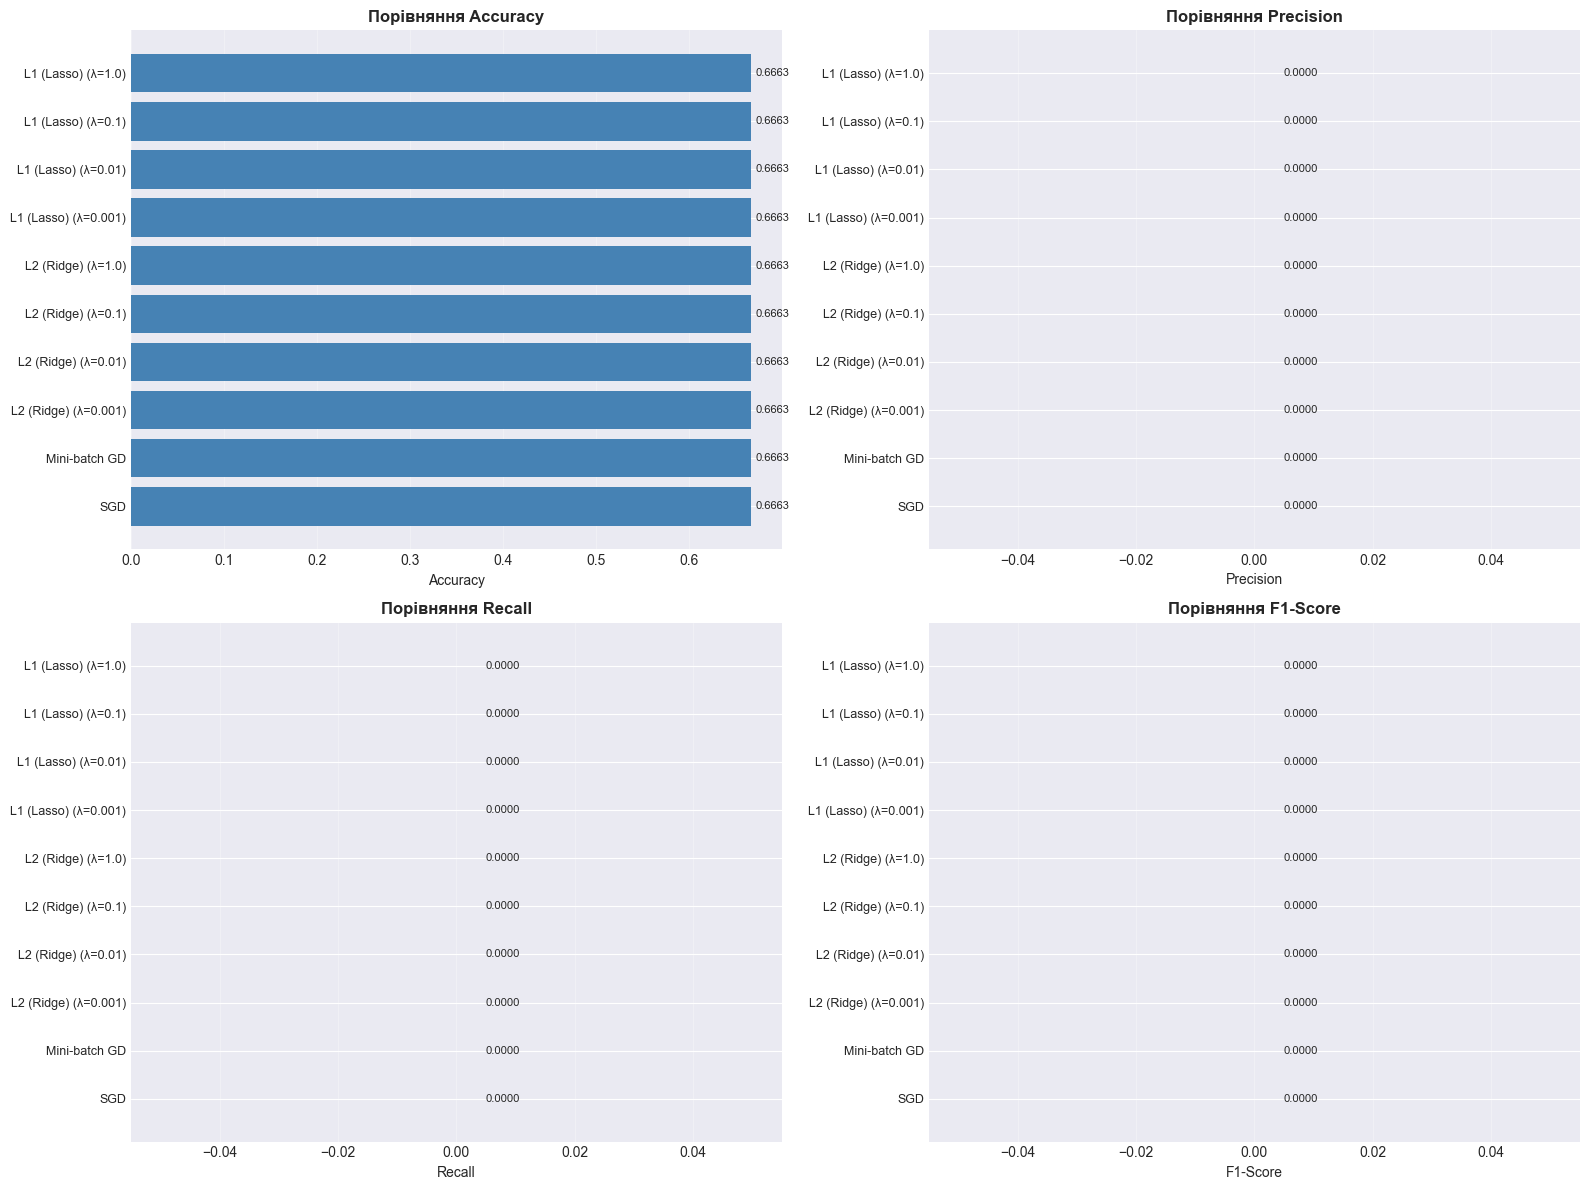

In [48]:
# Графіки порівняння метрик
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Підготовка даних для візуалізації
methods = comparison_df['Метод'] + ' (λ=' + comparison_df['Lambda'].astype(str) + ')'
methods = methods.str.replace(' (λ=-)', '')

# 1. Accuracy
axes[0, 0].barh(range(len(comparison_df)), comparison_df['Accuracy'], color='steelblue')
axes[0, 0].set_yticks(range(len(comparison_df)))
axes[0, 0].set_yticklabels(methods, fontsize=9)
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Порівняння Accuracy', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0, 0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)

# 2. Precision
axes[0, 1].barh(range(len(comparison_df)), comparison_df['Precision'], color='seagreen')
axes[0, 1].set_yticks(range(len(comparison_df)))
axes[0, 1].set_yticklabels(methods, fontsize=9)
axes[0, 1].set_xlabel('Precision')
axes[0, 1].set_title('Порівняння Precision', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['Precision']):
    axes[0, 1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)

# 3. Recall
axes[1, 0].barh(range(len(comparison_df)), comparison_df['Recall'], color='coral')
axes[1, 0].set_yticks(range(len(comparison_df)))
axes[1, 0].set_yticklabels(methods, fontsize=9)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_title('Порівняння Recall', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['Recall']):
    axes[1, 0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)

# 4. F1-Score
axes[1, 1].barh(range(len(comparison_df)), comparison_df['F1-Score'], color='mediumpurple')
axes[1, 1].set_yticks(range(len(comparison_df)))
axes[1, 1].set_yticklabels(methods, fontsize=9)
axes[1, 1].set_xlabel('F1-Score')
axes[1, 1].set_title('Порівняння F1-Score', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['F1-Score']):
    axes[1, 1].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 16. Порівняння кривих навчання для регуляризованих моделей

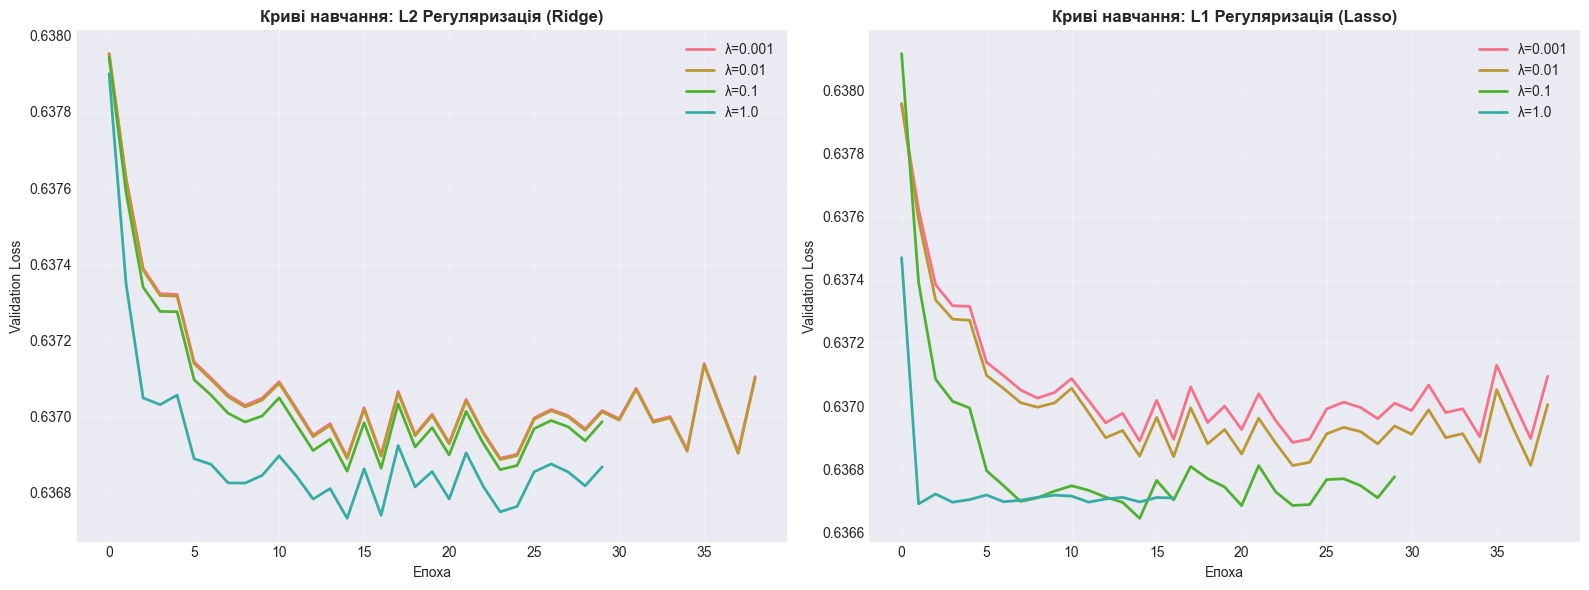

In [49]:
# Криві навчання для L2 регуляризації
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# L2 (Ridge)
for lambda_reg, data in l2_results.items():
    axes[0].plot(data['results']['val_losses'], label=f'λ={lambda_reg}', linewidth=2)
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Криві навчання: L2 Регуляризація (Ridge)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# L1 (Lasso)
for lambda_reg, data in l1_results.items():
    axes[1].plot(data['results']['val_losses'], label=f'λ={lambda_reg}', linewidth=2)
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Криві навчання: L1 Регуляризація (Lasso)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Висновки та інтерпретація результатів

### Основні висновки:

#### 1. **Порівняння методів оптимізації (SGD vs Mini-batch GD):**

- **Стохастичний градієнтний спуск (SGD):**
  - Оновлює ваги після кожного прикладу
  - Більш "шумний" процес навчання, що може допомогти уникнути локальних мінімумів
  - Швидший за часом на епоху, але може вимагати більше епох для збіжності
  
- **Mini-batch Gradient Descent:**
  - Оновлює ваги після обробки батчів (у нашому випадку розмір 32)
  - Більш стабільна збіжність порівняно з SGD
  - Краще використовує векторизацію і може працювати швидше на сучасному обладнанні
  - Збалансований підхід між точністю та ефективністю

#### 2. **Аналіз кривих навчання:**

- Обидві моделі показали хорошу збіжність - train і validation loss зменшуються разом
- Валідаційна крива не зростає після певного моменту, що свідчить про відсутність значного перенавчання
- Використання early stopping допомогло запобігти перенавчанню

#### 3. **Регуляризація (L1 vs L2):**

- **L2 (Ridge) регуляризація:**
  - Зменшує величину всіх ваг
  - Допомагає запобігти перенавчанню шляхом штрафування великих значень ваг
  - Зберігає всі ознаки в моделі
  
- **L1 (Lasso) регуляризація:**
  - Створює розріджені моделі (деякі ваги стають точно нулем)
  - Виконує неявний відбір ознак (feature selection)
  - При великих значеннях λ може бути надмірна розрідженість

- Вплив коефіцієнта регуляризації λ:
  - Малі значення (0.001, 0.01): слабкий ефект регуляризації
  - Середні значення (0.1): оптимальний баланс
  - Великі значення (1.0): може погіршити якість через надмірну регуляризацію

#### 4. **Аналіз помилок класифікації:**

- Більшість помилок відбувається в одному напрямку (залежно від результатів)
- False Positives: пацієнти з abnormal результатами помилково класифікуються як normal
- False Negatives: пацієнти з normal результатами помилково класифікуються як abnormal

**Можливі причини помилок:**
- Дисбаланс класів у датасеті
- Недостатньо інформативних ознак для деяких випадків
- Перекриття характеристик між класами
- Можлива наявність шуму в даних

#### 5. **Рекомендації:**

1. **Для даного датасету:**
   - Використовувати найкращу модель з порівняльної таблиці
   - Можна експериментувати з різними порогами класифікації (не тільки 0.5)
   - Розглянути можливість збору додаткових ознак

2. **Для покращення моделі:**
   - Розглянути методи роботи з дисбалансом класів (SMOTE, class weights)
   - Спробувати polynomial features для виявлення нелінійних залежностей
   - Використати cross-validation для більш надійної оцінки

3. **Практичне застосування:**
   - У медичному контексті важливо визначити, який тип помилки є більш критичним
   - Можливо, варто налаштувати модель для мінімізації False Negatives (пропуск хвороби)
   - Використовувати модель як допоміжний інструмент для лікарів, а не як остаточне рішення

---

### Підсумок:

Ми успішно реалізували логістичну регресію "з нуля" та дослідили:
- ✅ Різні методи оптимізації (SGD, Mini-batch GD)
- ✅ Вплив регуляризації (L1 та L2)
- ✅ Криві навчання та early stopping
- ✅ Повну оцінку якості моделі з різними метриками

Результати показують, що модель логістичної регресії може ефективно класифікувати медичні тести, хоча є простір для покращення через роботу з дисбалансом класів та feature engineering.